# `TrnTestEntrySpice`: SPICE-only test entries, no EDR required

Every other notebook in this repo builds a `TrnTestEntry` from a real LROC WAC EDR: the EDR's own
PDS4 label gives a timestamp, and its own ISIS-processed crop gives the ground truth
`camera.build_camera` re-aims the synthetic camera's boresight against. But the piece a `hillshade`
render actually needs is smaller than that -- just a camera model (a time, a 6-DOF pose, and pinhole
intrinsics) evaluated at some SPICE-resolvable moment. `TrnTestEntrySpice` (see
`src/trntest/trn_dataset.py`) is that smaller abstraction: no EDR, no ISIS pipeline, no real
acquired image anywhere in its own construction.

This is a proof of concept, deliberately narrow: only `hillshade` is supported (there's no EDR
pixel data for `crop`/`reproject` to work from). Each entry's `primary_generator` is `"hillshade"`,
so `entry.primary_image` -- what other code displays as "the" representative image -- is the
`hillshade` render wherever a `crop` panel would normally go.

Five entries: the first and last EDR timestamps of one real orbit, plus three
`np.linspace`-interpolated points between them -- a short, evenly-spaced pose sequence along a real
ground track, without needing five separate real acquisitions.

In [1]:
import numpy as np
import pandas as pd
import spiceypy as spice

import trntest
from trntest import camera, candidate_window, dataset_selection, illumination
from trntest.config import load_config

config = load_config()

## Step 1: the same "first selected dataset" `select_datasets.py` finds

Reuses that notebook's own orbit-selection pipeline (`dataset_selection.find_orbits` ->
`add_acceptable_edr_counts` -> `add_maneuver_flags` -> `enumerate_candidate_datasets` ->
`select_diverse_datasets`), unchanged parameters, so `selected_datasets.iloc[0]` names the exact
same real orbit sequence that notebook's own first pick does. See that notebook for what each step
means -- this cell is just the pipeline calls, without the exploratory plots.

In [2]:
PERIOD_START = pd.Timestamp("2019-01-01").to_pydatetime()
PERIOD_END = pd.Timestamp("2020-01-01").to_pydatetime()  # exclusive
MIN_SUN_ELEVATION_DEG = 15.0
MAX_EMISSION_ANGLE_DEG = 15.0
DATASET_LENGTH_ORBITS = 24
MIN_EDR_COUNT_PER_ORBIT = 3
MIN_CENTER_LONGITUDE_SEPARATION_DEG = 12.0
N_DATASETS = 20

orbits_df = dataset_selection.find_orbits(PERIOD_START, PERIOD_END, config)
orbits_df = dataset_selection.add_acceptable_edr_counts(
    orbits_df, PERIOD_START, PERIOD_END, config, MIN_SUN_ELEVATION_DEG, MAX_EMISSION_ANGLE_DEG
)
orbits_df = dataset_selection.add_maneuver_flags(orbits_df, PERIOD_START, PERIOD_END, config)
candidates_df = dataset_selection.enumerate_candidate_datasets(
    orbits_df, DATASET_LENGTH_ORBITS, MIN_EDR_COUNT_PER_ORBIT
)
selected_datasets = dataset_selection.select_diverse_datasets(
    candidates_df, MIN_CENTER_LONGITUDE_SEPARATION_DEG, N_DATASETS
)
orbit_sequence = selected_datasets.iloc[0]
orbit_sequence[["start_idx", "end_idx", "start_utc", "end_utc"]]

4485 complete orbits in 2019-01-01..2020-01-01


  (4 of 18995 skipped -- SPICE coverage edge case, treated as rejected)


53324 WAC EDRs in the period, 18772 acceptable (sun_elev > 15.0 deg, emission < 15.0 deg, within 5.0 deg of nominal boresight pointing)


20 maneuver candidates over the whole period, 20 orbits flagged
2847 / 4485 individually acceptable orbits
2170 acceptable candidate datasets out of 4462 possible 24-orbit windows


start_idx                                1903
end_idx                                  1926
start_utc    2019-06-04 18:58:02.819000+00:00
end_utc      2019-06-06 15:46:34.214000+00:00
Name: 0, dtype: object

## Step 2: narrow to just that sequence's first orbit

`orbit_sequence` spans `DATASET_LENGTH_ORBITS` orbits -- we only want its own first one, not the
whole span. `orbits_df.iloc[orbit_sequence["start_idx"]]` is that single orbit's own row; its
`asc_et`/`next_asc_et` (ascending node to the next one, one full orbit period) bound the window.
`candidate_window.images_for_window` resolves every acceptable real WAC EDR inside it, the same
per-candidate evaluation `dataset_selection.resolve_orbit_sequence` uses for a whole sequence.

In [3]:
first_orbit = orbits_df.iloc[int(orbit_sequence["start_idx"])]
orbit_start_utc = illumination.et_to_datetime(first_orbit["asc_et"])
orbit_end_utc = illumination.et_to_datetime(first_orbit["next_asc_et"])

orbit_images = candidate_window.images_for_window(
    orbit_start_utc,
    orbit_end_utc,
    config,
    MIN_SUN_ELEVATION_DEG,
    attach_cdr=False,
    max_emission_angle_deg=MAX_EMISSION_ANGLE_DEG,
)
print(f"{len(orbit_images)} acceptable EDR(s) in this orbit ({orbit_start_utc} .. {orbit_end_utc})")
orbit_images[["product_id", "start_time"]]

9 acceptable EDR(s) in this orbit (2019-06-04 17:58:40.437000+00:00 .. 2019-06-04 19:55:35.327000+00:00)


,product_id,start_time
0,M1314312388CE,2019-06-04 18:32:00.386000+00:00
1,M1314312770CE,2019-06-04 18:38:22.463000+00:00
2,M1314313032CE,2019-06-04 18:42:44.567000+00:00
3,M1314313323CE,2019-06-04 18:47:35.678000+00:00
4,M1314313691CE,2019-06-04 18:53:44.016000+00:00
5,M1314314398CE,2019-06-04 19:05:30.386000+00:00
6,M1314314745CE,2019-06-04 19:11:17.559000+00:00
7,M1314314993CE,2019-06-04 19:15:25.386000+00:00
8,M1314315239CE,2019-06-04 19:19:31.786000+00:00


## Step 3: five timepoints along this orbit

The first and last acceptable EDR's own `start_time` as endpoints, converted to SPICE ephemeris
time; `np.linspace` fills in 3 evenly-spaced points between them, for 5 total. Each becomes one
`TrnTestEntrySpice` row -- `product_id` plus `utc_time`, the minimal schema
`trntest.SPICE_DATASET_COLUMNS` names.

In [4]:
et_first = spice.utc2et(orbit_images.iloc[0]["start_time"].strftime("%Y-%m-%dT%H:%M:%S.%f"))
et_last = spice.utc2et(orbit_images.iloc[-1]["start_time"].strftime("%Y-%m-%dT%H:%M:%S.%f"))
et_values = np.linspace(et_first, et_last, 5)

spice_images = pd.DataFrame(
    {
        "product_id": [f"spice_entry_{i}" for i in range(len(et_values))],
        "utc_time": [illumination.et_to_datetime(et) for et in et_values],
    }
)
spice_images

,product_id,utc_time
0,spice_entry_0,2019-06-04 18:32:00.386000+00:00
1,spice_entry_1,2019-06-04 18:43:53.236000+00:00
2,spice_entry_2,2019-06-04 18:55:46.086000+00:00
3,spice_entry_3,2019-06-04 19:07:38.936000+00:00
4,spice_entry_4,2019-06-04 19:19:31.786000+00:00


## Step 4: a template `.tsai` -- the same fixed sensor model production already uses

`TrnTestEntrySpice` needs intrinsics (`fu`/`fv`/`cu`/`cv`) from somewhere -- rather than fitting a
new one, it reuses `camera.build_camera`'s own default (`fixed_sensor=True`): the same
`camera.FIXED_FOCAL_LENGTH_PX`/centered-principal-point model every `hillshade`/`reproject` render
already uses in production, calibrated in `notebooks/sensor_calibration_scoping.py`. Building a
camera against the config's own built-in reference EDR gets a real `.tsai` file to read those
intrinsics back out of (`camera.read_tsai`, called internally by `build_spice_camera`) -- its own
pose is specific to that reference EDR and gets discarded; only the intrinsics are reused.

In [5]:
template_dataset_folder = config.output_dir / "spice_entry_poc"
template_tsai_path = template_dataset_folder / "_work" / "template_reference.tsai"
template_camera = camera.build_camera(config, output_tsai_path=template_tsai_path)
print(f"Template .tsai: {template_camera.tsai_path} (fu=fv={template_camera.focal_length_u_px:.3f} px)")

Template .tsai: /workspace/output/spice_entry_poc/_work/template_reference.tsai (fu=fv=1342.522 px)


## Step 5: build the dataset and render `hillshade` for each entry

`TrnTestDataSet.create(entry_kind="spice", ...)` copies `template_tsai_path` in as this dataset's
own shared `camera_template.tsai` and writes `spice_images` as `manifest.csv` --
`TrnTestDataSet.open()` can reload this dataset later the same way any EDR dataset reloads from its
own `manifest.csv`. `populate()` defaults to `("hillshade",)` for this entry kind (see
`TrnTestDataSet.default_product_types`) -- there's nothing else to generate.

In [6]:
spice_dataset = trntest.TrnTestDataSet.create(
    template_dataset_folder, spice_images, config, entry_kind="spice", template_tsai_path=template_tsai_path
)
spice_dataset.populate()

/workspace/output/spice_entry_poc: wrote status.csv for 5 entries (entry_kind='spice' -- report/gallery HTML generation isn't supported for this kind yet)


## Step 6: look at what got rendered

`entry.primary_image` is `entry.hillshade` for every entry here (`primary_generator="hillshade"`)
-- the same accessor `report.py`'s `primary_overlay` uses, standing in for `crop` wherever a
`crop`-vs-basemap panel would normally go for an EDR-based entry.

Not every entry is guaranteed to render: `dem_ortho.fetch_dem`'s Astropedia GLD100 source only
covers +-79 deg latitude, and an evenly-spaced SPICE timepoint sequence (unlike a hand-picked
single EDR) can wander past that edge for a high-inclination pass -- exactly the kind of real
system boundary this proof of concept is meant to surface, not hide. `populate()` above already
logged any such failure per entry (see `<dataset folder>/logs/<identifier>/hillshade_log.txt`);
this cell just reports which entries actually have a `hillshade` to look at.

In [7]:
rendered_entries = []
for entry in spice_dataset:
    ok = entry.primary_image.exists()
    status = "rendered" if ok else "FAILED (see its own log)"
    print(f"{entry.product_id}  off-nadir={entry.camera.off_nadir_deg:.2f} deg  -- {status}")
    if ok:
        rendered_entries.append(entry)
assert rendered_entries, "no entry rendered -- nothing to display below"

spice_entry_0  off-nadir=6.24 deg  -- FAILED (see its own log)
spice_entry_1  off-nadir=6.24 deg  -- rendered
spice_entry_2  off-nadir=6.24 deg  -- rendered
spice_entry_3  off-nadir=6.23 deg  -- rendered
spice_entry_4  off-nadir=6.23 deg  -- rendered


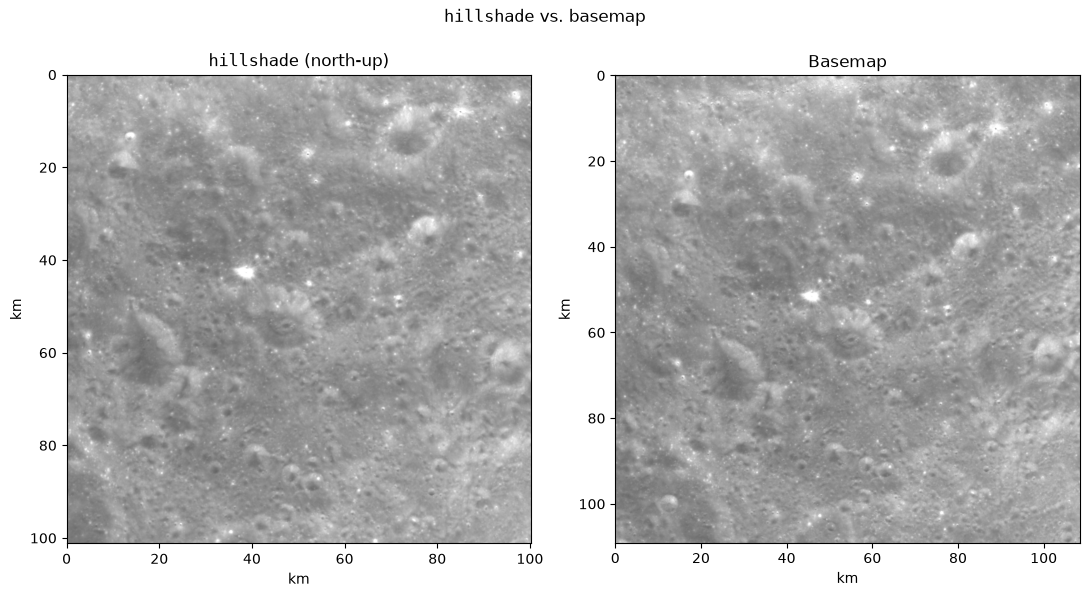

In [8]:
_ = rendered_entries[0].primary_image.plot_vs_basemap()


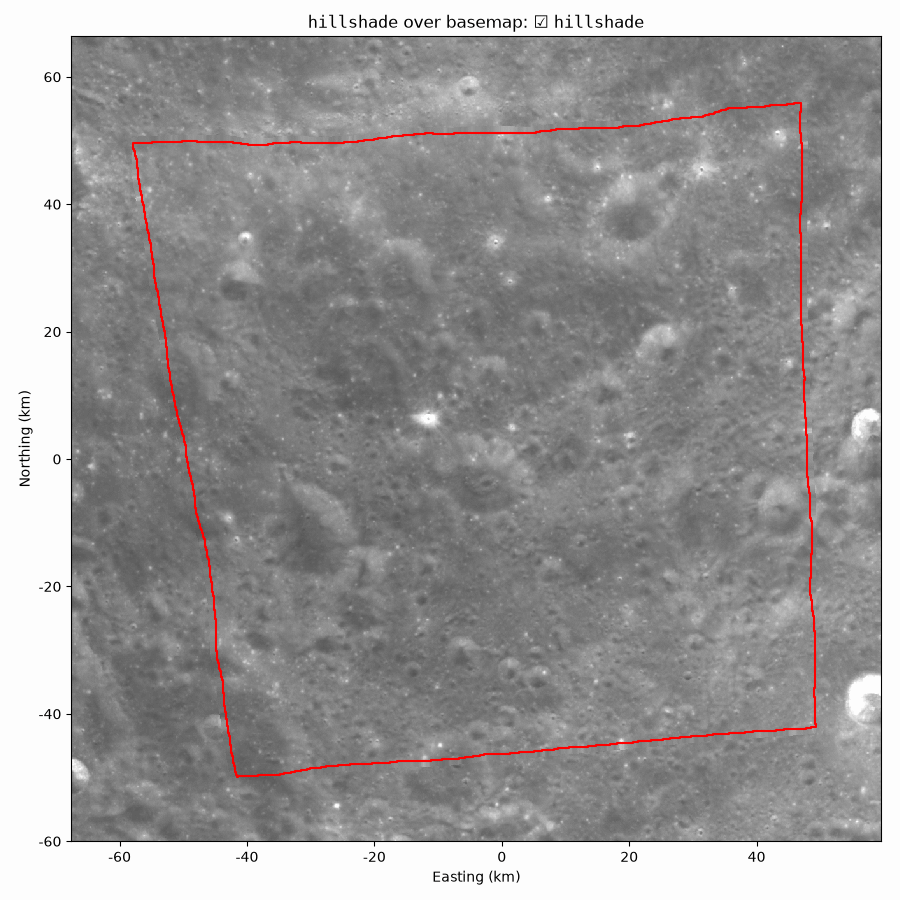

In [9]:
rendered_entries[0].primary_image.plot_overlay()


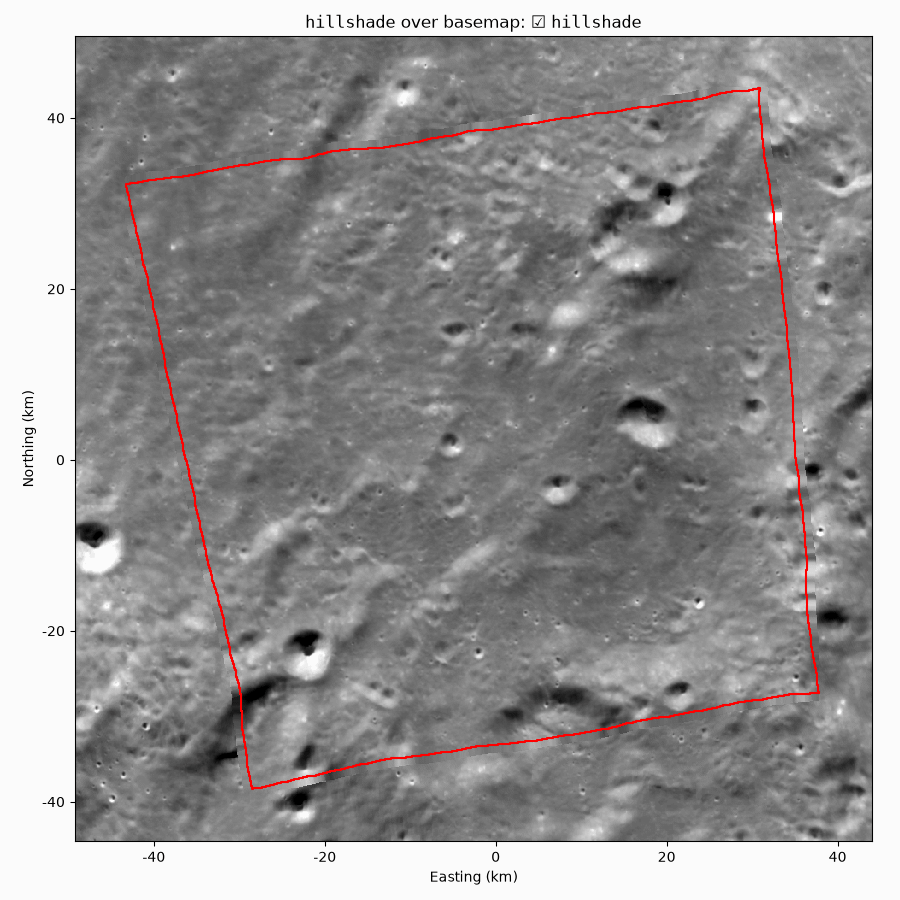

In [10]:
rendered_entries[-1].primary_image.plot_overlay()